<a href="https://colab.research.google.com/github/Abhii-00/ai_ml_lab/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import ipywidgets as widgets
from IPython.display import display, clear_output

In [4]:
# Upload dataset
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Titanic_Cleaned.csv")

# Display basic information
print("First 5 rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Saving Titanic_Cleaned.csv to Titanic_Cleaned (1).csv
First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1.0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,2
1,2.0,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3.0,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,1
3,4.0,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5.0,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,1



Dataset Shape: (891, 13)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
dtype: int64


In [5]:
# Select features
X = df[
    [
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'FamilySize',
        'Embarked'
    ]
]

# Target
y = df['Survived']

# Numerical features
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize'
]

# Categorical features
categorical_features = [
    'Sex',
    'Embarked'
]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [6]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

# Complete Logistic Regression pipeline
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Accuracy: 0.8044692737430168
Accuracy (%): 80.44692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[98 12]
 [23 46]]


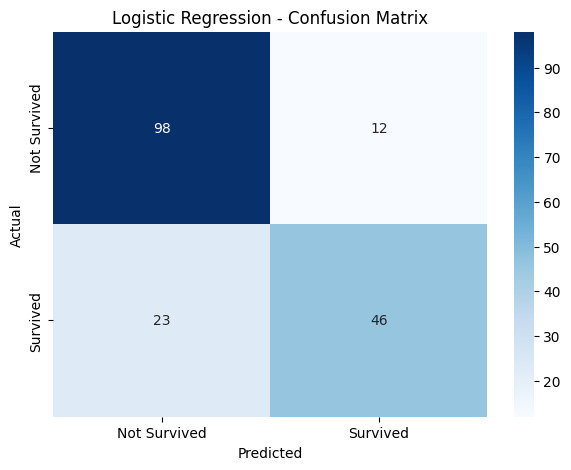

In [7]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [8]:
# Passenger Class
pclass = widgets.Dropdown(
    options=[
        ('1st Class', 1),
        ('2nd Class', 2),
        ('3rd Class', 3)
    ],
    value=3,
    description='Pclass:'
)

# Sex
sex = widgets.Dropdown(
    options=[
        ('Female', 'female'),
        ('Male', 'male')
    ],
    value='male',
    description='Sex:'
)

# Age
age = widgets.FloatText(
    value=25,
    description='Age:',
    min=0
)

# Siblings / Spouses
sibsp = widgets.IntText(
    value=0,
    description='SibSp:',
    min=0
)

# Parents / Children
parch = widgets.IntText(
    value=0,
    description='Parch:',
    min=0
)

# Fare
fare = widgets.FloatText(
    value=30.0,
    description='Fare:',
    min=0
)

# Family Size
family_size = widgets.IntText(
    value=1,
    description='Family Size:',
    min=1
)

# Embarked
embarked = widgets.Dropdown(
    options=[
        ('Cherbourg', 'C'),
        ('Queenstown', 'Q'),
        ('Southampton', 'S')
    ],
    value='S',
    description='Embarked:'
)

# Predict button
predict_button = widgets.Button(
    description='Predict Survival',
    button_style='success',
    icon='check'
)

# Output area
output = widgets.Output()

In [9]:
def predict_survival(button):

    with output:
        clear_output()

        # Create new passenger from GUI input
        new_passenger = pd.DataFrame({
            'Pclass': [pclass.value],
            'Sex': [sex.value],
            'Age': [age.value],
            'SibSp': [sibsp.value],
            'Parch': [parch.value],
            'Fare': [fare.value],
            'FamilySize': [family_size.value],
            'Embarked': [embarked.value]
        })

        # Prediction
        prediction = model.predict(new_passenger)[0]

        # Prediction probabilities
        probability = model.predict_proba(new_passenger)[0]

        not_survived_probability = probability[0]
        survived_probability = probability[1]

        print("========== Titanic Survival Prediction ==========\n")

        if prediction == 1:
            print("Prediction: SURVIVED")
        else:
            print("Prediction: NOT SURVIVED")

        print("\nProbability:")
        print(
            f"Survived:     {survived_probability * 100:.2f}%"
        )
        print(
            f"Not Survived: {not_survived_probability * 100:.2f}%"
        )

In [10]:
# Connect button to prediction function
predict_button.on_click(predict_survival)

# GUI title
title = widgets.HTML(
    value="<h2>Titanic Survival Prediction</h2>"
)

description = widgets.HTML(
    value="<p>Enter the details of a new passenger:</p>"
)

# Display GUI
display(
    title,
    description,
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    family_size,
    embarked,
    predict_button,
    output
)

HTML(value='<h2>Titanic Survival Prediction</h2>')

HTML(value='<p>Enter the details of a new passenger:</p>')

Dropdown(description='Pclass:', index=2, options=(('1st Class', 1), ('2nd Class', 2), ('3rd Class', 3)), value…

Dropdown(description='Sex:', index=1, options=(('Female', 'female'), ('Male', 'male')), value='male')

FloatText(value=25.0, description='Age:')

...

FloatText(value=30.0, description='Fare:')

IntText(value=1, description='Family Size:')

Dropdown(description='Embarked:', index=2, options=(('Cherbourg', 'C'), ('Queenstown', 'Q'), ('Southampton', '…

Button(button_style='success', description='Predict Survival', icon='check', style=ButtonStyle())

Output()